In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install kneed
from kneed import KneeLocator
import seaborn as sns

### Sorry Telat Ce aku Dari Rumah lagi sakit ga enak badan. Thank you Ceee

# Exploratory Data Analysis

In [79]:
# load dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/mall_customers.csv"
df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [80]:
df_cluster = df

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [82]:
print(df.shape)

(200, 5)


In [83]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


1. Kualitas Data Sangat Baik
  - Tidak Ada Data Hilang (Missing Values): Setiap kolom memiliki 200 entri non-null sehingga tidak perlu membersihkan data yang hilang.
  - Tipe Data (Dtype) Sesuai: Semua kolom numerik (Age, Income, Score) sudah benar terbaca sebagai int64. Kolom Gender bertipe object (teks). Kolom ini perlu diubah menjadi angka dengan encoding.

2. Analisis per Kolom
  - CustomerID: Ini hanya sebagai identifier dari 1 s.d. 200. Kolom ini tidak berguna secara statistik untuk analisis dan akan dibuang sebelum pemodelan.
  - Age (Usia):
    - Rentang usia pelanggan adalah dari 18 hingga 70 tahun.
    - Rata-rata (mean) usia adalah ~39 tahun, sementara nilai tengah (median/50%) adalah 36 tahun. Ini menunjukkan data sedikit condong ke pelanggan yang lebih muda, tapi secara umum distribusinya bagus.
    - 50% pelanggan (IQR) berada di rentang usia 28 s.d. 49 tahun.
  - Annual Income (k$) (Pendapatan Tahunan):
    - Terdapat rentang pendapatan yang sangat lebar, dari $15k hingga $137k.
    - Nilai rata-rata ($60.5k) dan median ($61.5k) sangat berdekatan. Ini mengindikasikan distribusi pendapatan simetris (normal) dan tidak didominasi oleh segelintir orang yang super kaya.
  - Spending Score (1-100) (Skor Belanja):
    - Skornya menggunakan rentang penuh, dari 1 hingga 99.
    - Nilai rata-rata (50.2) dan median (50.0) hampir persis di tengah. Ini temuan kunci: pelanggan tidak secara alami condong ke hemat atau boros. Mereka tersebar merata di seluruh spektrum belanja.

## Encoding

In [84]:
# Gender Encoding to make it numerical

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [85]:
# Mengganti nama kedua kolom agar lebih bersih
df = df.rename(columns={
    "Annual Income (k$)": "Annual Income",
    "Spending Score (1-100)": "Spending Score"
})

df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


## Visualization

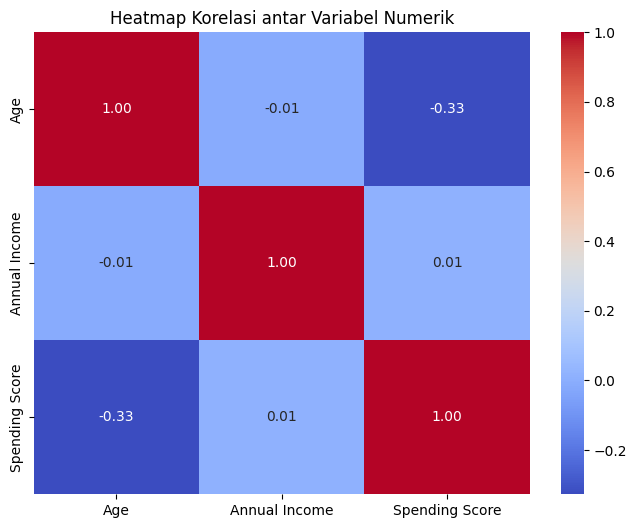

In [86]:
# Pilih hanya kolom numerik yang relevan untuk korelasi
numerical_df = df[['Age', 'Annual Income', 'Spending Score']]

plt.figure(figsize=(8, 6))
sns.heatmap(
    numerical_df.corr(), # Menghitung korelasi
    annot=True,          # Menampilkan angka di dalam kotak
    cmap='coolwarm',     # Skema warna (biru=negatif, merah=positif)
    fmt='.2f'            # Format angka (2 angka desimal)
)
plt.title('Heatmap Korelasi antar Variabel Numerik')
plt.show()

Heatmap di atas menunjukkan korelasi antar variabel numerik yaitu Age, Annual Income, dan Spending Score. Dari hasilnya, terlihat bahwa tidak ada hubungan yang kuat antara ketiga variabel tersebut. Korelasi antara Age dan Spending Score bernilai -0.33, menandakan hubungan negatif lemah—semakin tua usia seseorang, cenderung semakin rendah Spending Score-nya, yang berarti pelanggan yang lebih tua lebih berhati-hati dalam pengeluaran. Sementara itu, korelasi antara Annual Income dengan Spending Score hampir tidak ada (0.01), menunjukkan bahwa tingkat pendapatan tidak secara signifikan memengaruhi seberapa besar seseorang berbelanja. Korelasi antara Age dan Annual Income juga sangat kecil (-0.01), yang berarti usia tidak berpengaruh terhadap besaran pendapatan dalam dataset ini. Secara keseluruhan, hubungan antar variabel bersifat lemah dan independen, sehingga faktor lain di luar ketiga variabel ini kemungkinan besar memengaruhi perilaku belanja pelanggan.

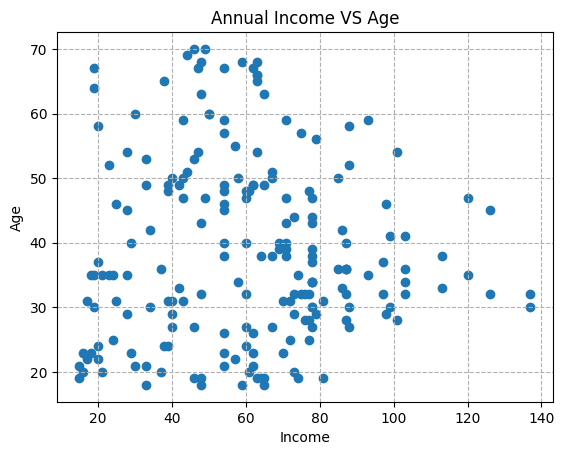

In [87]:
plt.scatter(df['Annual Income'], df['Age'])
plt.title('Annual Income VS Age')
plt.xlabel('Income')
plt.ylabel('Age')
plt.grid(axis='both', linestyle='--')
plt.show()

Grafik scatter di atas menunjukkan hubungan antara Annual Income (pendapatan tahunan) dan Age (usia pelanggan). Titik-titik data tersebar secara acak tanpa pola yang jelas, menandakan bahwa tidak ada korelasi yang kuat antara usia dan pendapatan. Pelanggan dengan usia muda, menengah, maupun tua dapat memiliki tingkat pendapatan yang beragam mulai dari rendah hingga tinggi. Hal ini mengindikasikan bahwa faktor usia tidak menjadi penentu utama dalam menentukan besar kecilnya pendapatan pelanggan dalam dataset ini. Distribusi yang acak ini juga sejalan dengan hasil korelasi sebelumnya (sekitar -0.01), yang memperkuat kesimpulan bahwa usia dan pendapatan bersifat independen satu sama lain dalam konteks populasi ini.

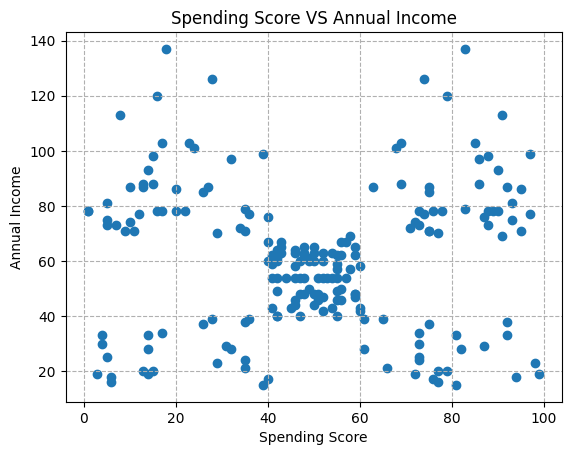

In [88]:
plt.scatter(df['Spending Score'], df['Annual Income'])
plt.title('Spending Score VS Annual Income')
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.grid(axis='both', linestyle='--')
plt.show()

Grafik di atas menunjukkan hubungan antara Spending Score (tingkat pengeluaran pelanggan) dan Annual Income (pendapatan tahunan pelanggan). Dari plot tersebut, terlihat bahwa pelanggan dengan pendapatan menengah (sekitar 40–70 ribu) tersebar cukup padat di berbagai tingkat pengeluaran, menandakan adanya variasi perilaku konsumsi dalam kelompok pendapatan menengah ini. Pelanggan berpendapatan tinggi (di atas 100 ribu) umumnya memiliki variasi pengeluaran yang lebih besar, namun sebagian besar tidak menghabiskan terlalu banyak, menunjukkan perilaku konsumsi yang lebih konservatif. Sebaliknya, pelanggan dengan pendapatan rendah (di bawah 40 ribu) cenderung memiliki Spending Score yang beragam, mungkin karena perbedaan prioritas belanja atau kebutuhan tertentu. Secara keseluruhan, tidak terdapat korelasi linier yang kuat antara pendapatan dan pengeluaran, mengindikasikan bahwa pendapatan bukan satu-satunya faktor yang menentukan perilaku belanja pelanggan.

In [89]:
# create new dataframe that consist only annual income and spending score
df = df[['Spending Score', 'Annual Income']]
df.head()

,Spending Score,Annual Income
0,39,15
1,81,15
2,6,16
3,77,16
4,40,17


# Data Scaling (Choose One)

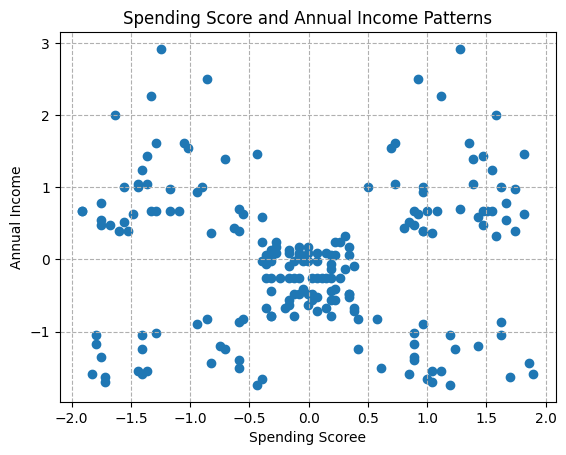

In [90]:
# scale dataset with standard scaler

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

df_sc_scaled = pd.DataFrame(sc.fit_transform(df), columns=["Spending Score", "Annual Income"])

df_sc_scaled.head()

# visualization
plt.scatter(df_sc_scaled["Spending Score"], df_sc_scaled["Annual Income"])
plt.xlabel("Spending Scoree")
plt.ylabel("Annual Income")
plt.grid(axis='both', linestyle='--')
plt.title("Spending Score and Annual Income Patterns")
plt.show()

Scaling sangat penting karena algoritma berbasis jarak seperti K-Means, DBSCAN, atau Hierarchical Clustering menggunakan perhitungan jarak (misalnya Euclidean distance) untuk mengelompokkan data.

Tanpa scaling:

- Variabel dengan rentang nilai besar (misalnya “Annual Income” dalam ratusan ribu) akan mendominasi hasil perhitungan jarak.
- Variabel dengan rentang kecil (misalnya “Spending Score” dalam puluhan) akan diabaikan oleh model.

Dengan scaling:

- Semua fitur berada pada skala yang sama, sehingga setiap fitur memiliki pengaruh yang seimbang dalam pembentukan cluster.
- Hasil clustering menjadi lebih akurat dan representatif terhadap pola data sebenarnya.

# K-Means Clustering

In [91]:
from sklearn.cluster import KMeans

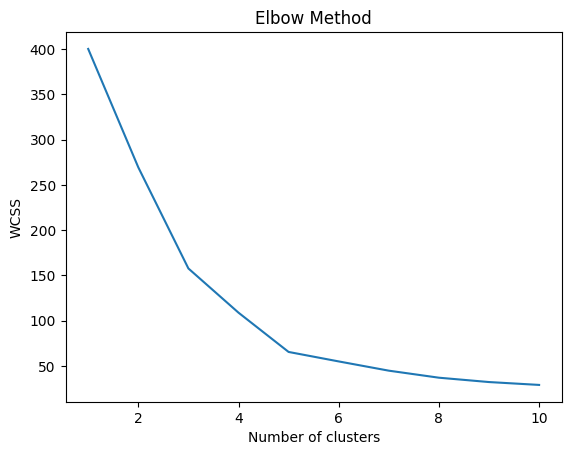

In [92]:
wcss = []
for i in range(1, 11):   #clusters 1-10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_sc_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [93]:
# Create a DataFrame to display the WCSS values for each number of clusters
wcss_table = pd.DataFrame({
    "Number of Clusters": range(1, 11),
    "WCSS": wcss
})

# Display the table
print(wcss_table)

   Number of Clusters        WCSS
0                   1  400.000000
1                   2  269.299343
2                   3  157.704008
3                   4  108.921317
4                   5   65.568408
5                   6   55.114226
6                   7   44.911186
7                   8   37.148117
8                   9   32.345838
9                  10   29.178990


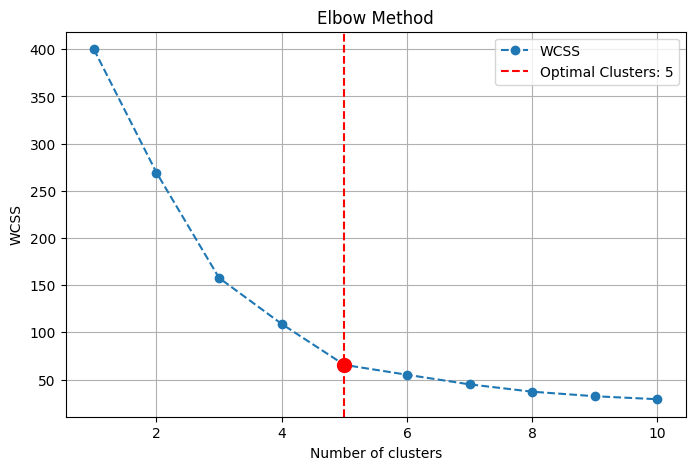

The optimal number of clusters is: 5


In [94]:
# Example WCSS values and cluster numbers
clusters = range(1, 11)

# Automatically find the elbow point using the KneeLocator
knee_locator = KneeLocator(clusters, wcss, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(clusters, wcss, marker='o', linestyle='--', label="WCSS")
plt.axvline(optimal_clusters, linestyle='--', color='red', label=f'Optimal Clusters: {optimal_clusters}')
plt.scatter(optimal_clusters, wcss[optimal_clusters-1], c='red', s=100, zorder=5)  # Highlight elbow point
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()

# Print the optimal number of clusters
print(f"The optimal number of clusters is: {optimal_clusters}")

Plot Elbow Method di atas menunjukkan hubungan antara jumlah cluster (K) dan Within-Cluster Sum of Squares (WCSS), yaitu ukuran seberapa rapat data dalam setiap cluster. Saat nilai K meningkat dari 2 hingga 10, nilai WCSS terus menurun hal ini wajar karena semakin banyak cluster yang dibuat, jarak antara titik data dengan pusat clusternya akan semakin kecil.

Namun, titik penting dalam grafik ini adalah bagian yang disebut “elbow” (siku), yaitu ketika penurunan WCSS mulai melambat secara signifikan. Pada grafik di atas, titik siku terlihat pada K = 5, yang ditandai dengan garis vertikal merah dan titik merah besar. Titik ini menunjukkan bahwa dengan 5 cluster, model sudah mencapai keseimbangan terbaik antara akurasi (kompaknya cluster) dan kesederhanaan model.

Dengan kata lain, menambah jumlah cluster lebih dari 5 hanya akan sedikit memperbaiki hasil (penurunan WCSS kecil), sehingga K = 5 dianggap sebagai jumlah cluster optimal. Artinya, data kemungkinan terbagi secara alami menjadi lima kelompok atau segmen pelanggan yang berbeda.

In [95]:
# Fit K-Means to the data with the optimal number of K cluster = 3
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, random_state=0)
clusters = kmeans.fit_predict(df_sc_scaled)

# Add the cluster labels to the DataFrame
df['KMeans_Cluster'] = clusters

# Show the df
df.head()

,Spending Score,Annual Income,KMeans_Cluster
0,39,15,3
1,81,15,4
2,6,16,3
3,77,16,4
4,40,17,3


/tmp/ipython-input-397200006.py:4: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x = "Spending Score", y = "Annual Income", hue=clusters, palette=["blueviolet", "red", "deepskyblue"], data=df_sc_scaled, s = 60)


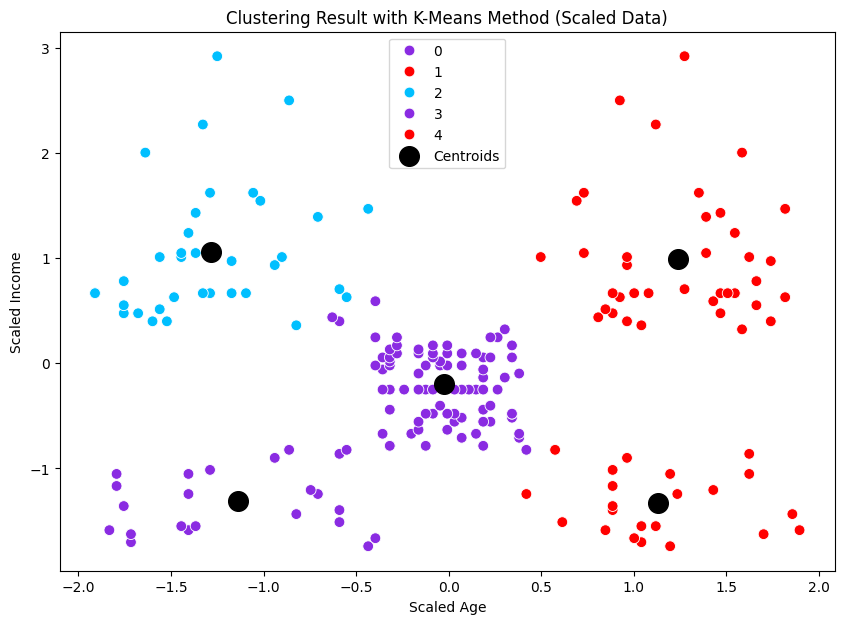

In [96]:
# visualize the result using scater chart on scaled data
plt.figure(figsize=(10,7))

sns.scatterplot(x = "Spending Score", y = "Annual Income", hue=clusters, palette=["blueviolet", "red", "deepskyblue"], data=df_sc_scaled, s = 60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c="black", label="Centroids")
plt.xlabel("Scaled Age")
plt.ylabel("Scaled Income")
plt.title("Clustering Result with K-Means Method (Scaled Data)")
plt.legend()
plt.show()

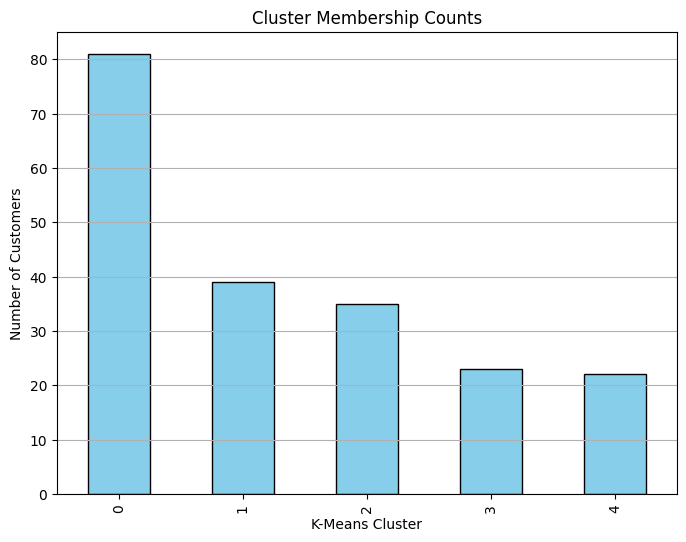

In [97]:
cluster_counts = df['KMeans_Cluster'].value_counts()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cluster Membership Counts')
plt.xlabel('K-Means Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.show()


In [98]:
df_cluster.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [99]:
# Group the data by cluster and calculate the mean spending and annual income for each cluster
df_cluster['KMeans_Cluster'] = df['KMeans_Cluster']

cluster_summary = df_cluster.groupby('KMeans_Cluster').agg({
    'Age': ['mean', 'median', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'median', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'median', 'min', 'max'],
    'Gender': lambda x: x.mode()[0]
})
cluster_summary

Age                Annual Income (k$)                  \
                     mean median min max               mean median min  max   
KMeans_Cluster                                                                
0               42.716049   46.0  18  70          55.296296   54.0  39   76   
1               32.692308   32.0  27  40          86.538462   79.0  69  137   
2               41.114286   42.0  19  59          88.200000   85.0  70  137   
3               45.217391   46.0  19  67          26.304348   25.0  15   39   
4               25.272727   23.5  18  35          25.727273   24.5  15   39   

               Spending Score (1-100)                  Gender  
                                 mean median min max <lambda>  
KMeans_Cluster                                                 
0                           49.518519   50.0  34  61        1  
1                           82.128205   83.0  63  97        1  
2                           17.114286   16.0   1  39        0  
3                           20.913043   17.0   3  40        1  
4                           79.363636   77.0  61  99        1

# Managerial Implications Based on the Three Clusters
1. Cluster 0 – Middle-Class Moderates
  - Usia menengah (sekitar 40-an) dengan pendapatan dan pengeluaran seimbang.
  - Belanja secara rasional dan stabil.
  - Cenderung loyal dan mencari kenyamanan serta nilai sepadan.

  Implikasi Manajerial:
  
    - Fokus pada retensi pelanggan melalui program loyalitas.
    - Promosi berbasis nilai (value for money) dan produk yang tahan lama.
    - Kampanye dapat dilakukan melalui email marketing dan voucher loyalitas.

2. Cluster 1 – Young Affluent Spenders
  - Usia muda (~30-an), pendapatan tinggi, dan Spending Score sangat tinggi.
  - Suka mencoba hal baru dan tidak ragu membayar lebih untuk kualitas.
  - Potensial sebagai pelanggan premium dan trendsetter.

Implikasi Manajerial:

    - Targetkan dengan produk premium atau edisi terbatas.
    - Gunakan media sosial dan influencer marketing.
    - Strategi personalized offers dan membership VIP efektif untuk retensi.

3. Cluster 2 – Wealthy Savers
  - Usia menengah (~40-an) dengan pendapatan tinggi, namun Spending Score rendah.
  - Cenderung berhati-hati dan selektif dalam pengeluaran.
  - Mungkin sudah mapan secara finansial, fokus pada nilai, bukan gaya hidup konsumtif.

Implikasi Manajerial:

    - Tawarkan produk berkualitas tinggi dengan diskon atau manfaat jangka panjang.
    - Gunakan pendekatan relationship marketing (konsultasi pribadi, keanggotaan eksklusif).
    - Upselling atau bundling bisa menarik segmen ini.

4. Cluster 3 – Low-Income Cautious Buyers

  - Usia matang (~45 tahun ke atas), pendapatan rendah, Spending Score rendah.
  - Belanja hanya untuk kebutuhan pokok.
  - Responsif terhadap harga dan promosi.

Implikasi Manajerial:

    - Fokus pada strategi harga kompetitif dan promo diskon.
    - Gunakan media tradisional atau SMS marketing.
    - Dorong produk kebutuhan dasar dengan nilai ekonomis.

5. Cluster 4 – Young Budget Spenders

  - Usia muda (~25 tahun), pendapatan rendah namun Spending Score tinggi.
  - Impulsif dan konsumtif, tertarik pada tren dan penawaran menarik.
  - Sering berbelanja secara emosional, bukan rasional.

Implikasi Manajerial:

    - Gunakan media sosial (TikTok, Instagram) untuk promosi.
    - Tawarkan produk bergaya dengan harga terjangkau.
    - Terapkan flash sale atau promo waktu terbatas untuk mendorong pembelian cepat.